# EDA (Explorarity Data Analysis)

**Loading Data from sql table**

In [2]:
import pandas as pd
from sqlalchemy import create_engine


DB_USER = "root"
DB_PASS = "root123"
DB_NAME = "ecommerce-churn-data"
DB_PORT = "3306"
DB_HOST = "localhost"

conn_str = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

df = pd.read_sql_table("ecommerce_churn", con=conn_str)
print(df)

      CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  \
0          50001      1     4.0         Mobile Phone         3   
1          50002      1     NaN                Phone         1   
2          50003      1     NaN                Phone         1   
3          50004      1     0.0                Phone         3   
4          50005      1     0.0                Phone         1   
...          ...    ...     ...                  ...       ...   
5625       55626      0    10.0             Computer         1   
5626       55627      0    13.0         Mobile Phone         1   
5627       55628      0     1.0         Mobile Phone         1   
5628       55629      0    23.0             Computer         3   
5629       55630      0     8.0         Mobile Phone         1   

      WarehouseToHome PreferredPaymentMode  Gender  HourSpendOnApp  \
0                 6.0           Debit Card  Female             3.0   
1                 8.0                  UPI    Male             3.0 

**Exploring Shape, dtypes, missing values, duplicate rows.**

In [3]:
print("## DF Shape is",df.shape)

## DF Shape is (5630, 20)


In [4]:
print(df.dtypes)

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


In [5]:
df.isnull().sum()


CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

**Overall churn rate — how imbalanced is it?**

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

**Univariate: distributions of Tenure, WarehouseToHome, SatisfactionScore, CashbackAmount.**

            Tenure  WarehouseToHome  SatisfactionScore  CashbackAmount
count  5366.000000      5379.000000        5630.000000     5630.000000
mean     10.189899        15.639896           3.066785      177.223030
std       8.557241         8.531475           1.380194       49.207036
min       0.000000         5.000000           1.000000        0.000000
25%       2.000000         9.000000           2.000000      145.770000
50%       9.000000        14.000000           3.000000      163.280000
75%      16.000000        20.000000           4.000000      196.392500
max      61.000000       127.000000           5.000000      324.990000
==================Skew=====================
Tenure               0.736513
WarehouseToHome      1.619154
SatisfactionScore   -0.142626
CashbackAmount       1.149846
dtype: float64
==================Missing Values=========================
Tenure               264
WarehouseToHome      251
SatisfactionScore      0
CashbackAmount         0
dtype: int64
===========

C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\934228198.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SatisfactionScore", data=df, ax=axes[3, 0], palette="Blues_d")


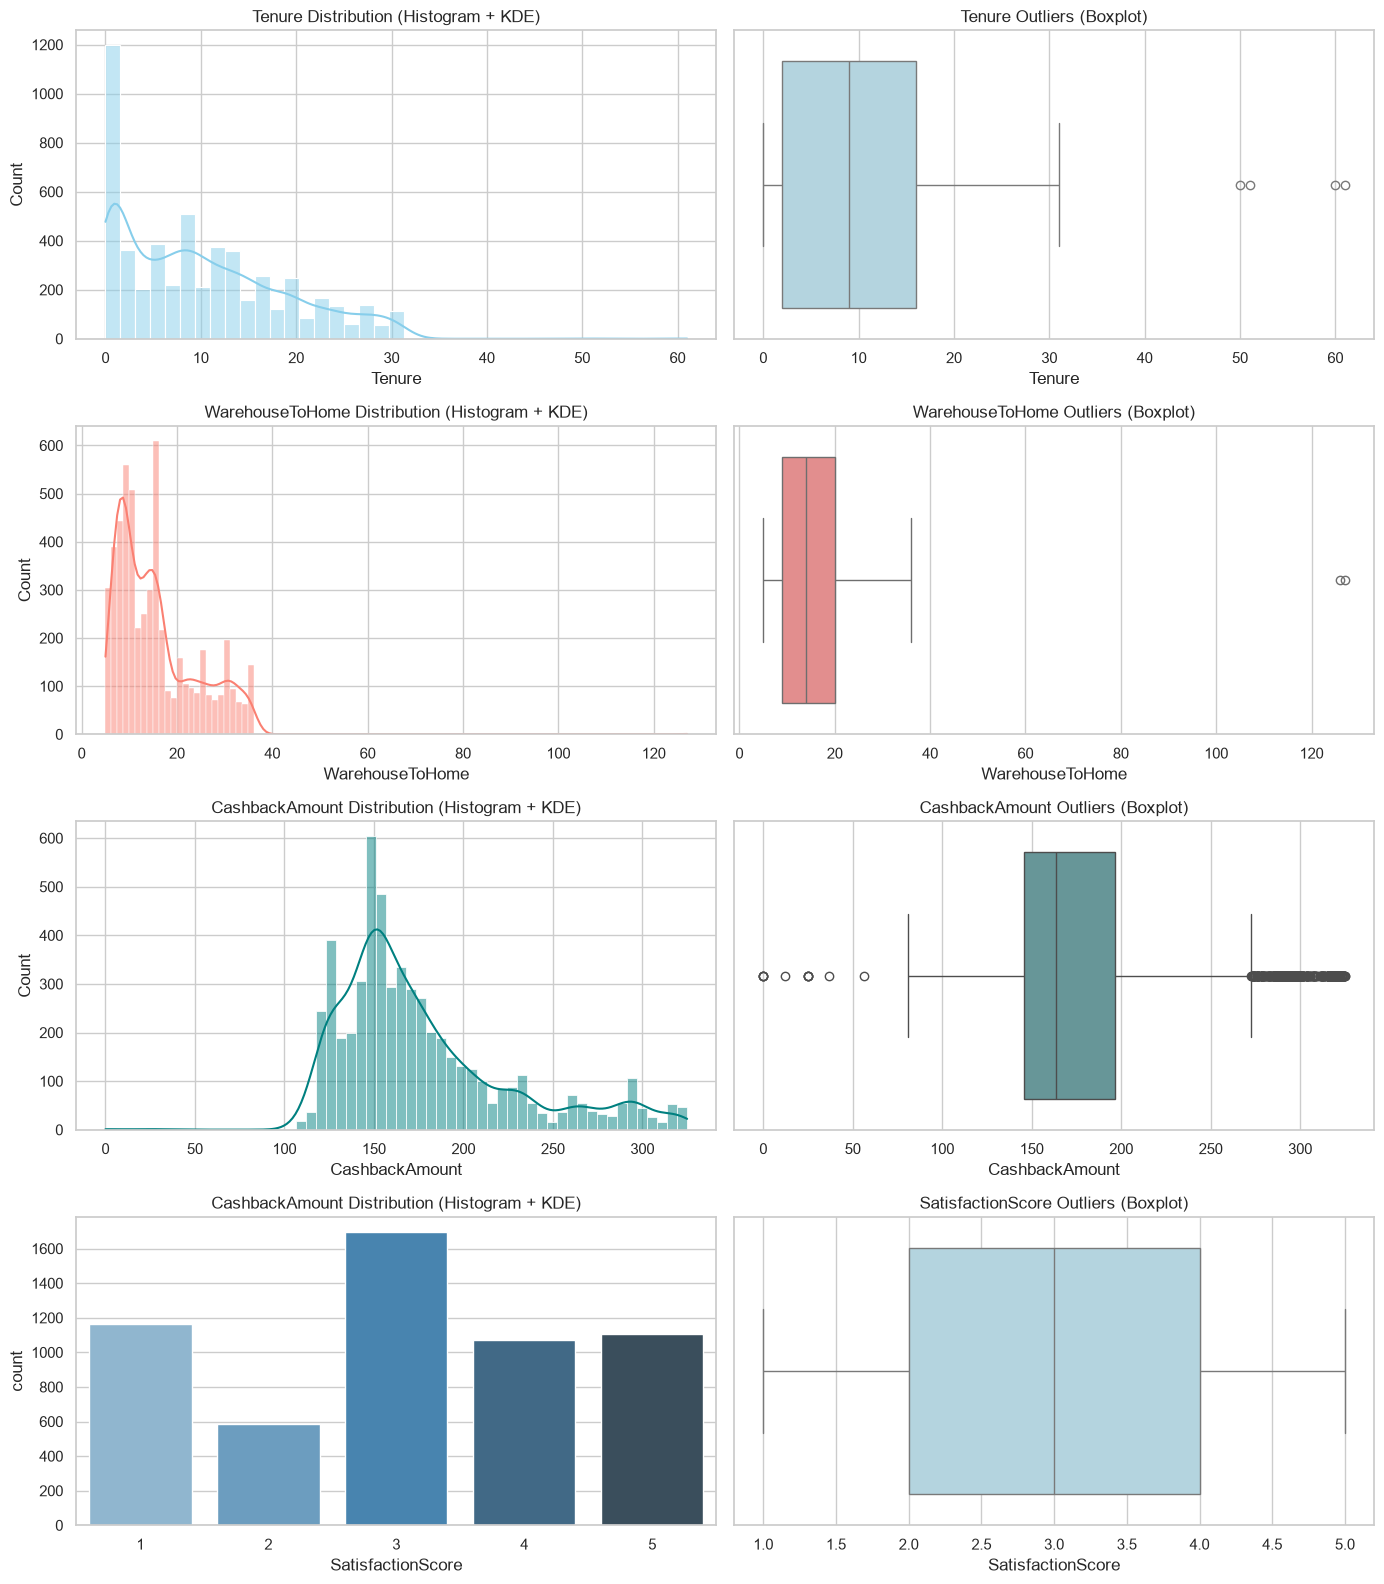

In [8]:
target_cols = ["Tenure", "WarehouseToHome", "SatisfactionScore", "CashbackAmount"]
print(df[target_cols].describe())

print("==================Skew=====================")
print(df[target_cols].skew())

print("==================Missing Values=========================")
print(df[target_cols].isnull().sum())

print("==================Plotting=======================================")
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

## 1 ---Tenure---
sns.histplot(df["Tenure"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Tenure Distribution (Histogram + KDE)")

sns.boxplot(x=df["Tenure"], ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Tenure Outliers (Boxplot)")

## 2 ---WarehouseToHome---
sns.histplot(df["WarehouseToHome"], kde=True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("WarehouseToHome Distribution (Histogram + KDE)")

sns.boxplot(x=df["WarehouseToHome"], ax=axes[1, 1], color="lightcoral")
axes[1, 1].set_title("WarehouseToHome Outliers (Boxplot)")

## 3 ---CashbackAmount---
sns.histplot(df["CashbackAmount"], kde=True, ax=axes[2, 0], color="teal")
axes[2, 0].set_title("CashbackAmount Distribution (Histogram + KDE)")

sns.boxplot(x=df["CashbackAmount"], ax=axes[2, 1], color="cadetblue")
axes[2, 1].set_title("CashbackAmount Outliers (Boxplot)")

## 4 ---SatisfactionScore---
sns.countplot(x="SatisfactionScore", data=df, ax=axes[3, 0], palette="Blues_d")
axes[3, 0].set_title("CashbackAmount Distribution (Histogram + KDE)")

sns.boxplot(x=df["SatisfactionScore"], ax=axes[3, 1], color="lightblue")
axes[3, 1].set_title("SatisfactionScore Outliers (Boxplot)")

plt.tight_layout()
plt.show()

**Bivariate vs. churn: CityTier, PreferredLoginDevice, MaritalStatus, Complain, PreferredPaymentMode.**

In [9]:
print(df["PreferredLoginDevice"].value_counts())
print(df["PreferredPaymentMode"].value_counts())

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
df["PreferredPaymentMode"].value_counts()

target_cols = ["CityTier", "PreferredLoginDevice", "MaritalStatus", "Complain", "PreferredPaymentMode"]
for col in target_cols:
    summary = df.groupby(col)["Churn"].agg(
        Total_Customers = "count",
        Churned_Customers = "sum",
        Churned_Rate_Pct = lambda x: round(x.mean() * 100, 2)
    ).reset_index()
    
    print("\n")
    print(f"{"="*30} {col} vs Churn Bivariate {"="*30}")
    print(summary)
    

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64


============================== CityTier vs Churn Bivariate ==============================
   CityTier  Total_Customers  Churned_Customers  Churned_Rate_Pct
0         1             3666                532             14.51
1         2              242                 48             19.83
2         3             1722                368             21.37


============================== PreferredLoginDevice vs Churn Bivariate ==============================
  PreferredLoginDevice  Total_Customers  Churned_Customers  Churned_Rate_Pct
0             Computer             1634                324             19.83
1                Phone             3996               

0    14.511729
1    19.834711
2    21.370499
Name: Churned_Pct, dtype: float64
0    19.828641
1    15.615616
Name: Churned_Pct, dtype: float64


C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\905735145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\905735145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\905735145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


0    14.622642
1    11.520429
2    26.726058
Name: Churned_Pct, dtype: float64
0    10.928962
1    31.670823
Name: Churned_Pct, dtype: float64
0    24.902724
1    14.205186
2    15.384615
3    22.801303
4    17.391304
Name: Churned_Pct, dtype: float64


C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\905735145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aboal\AppData\Local\Temp\ipykernel_10052\905735145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


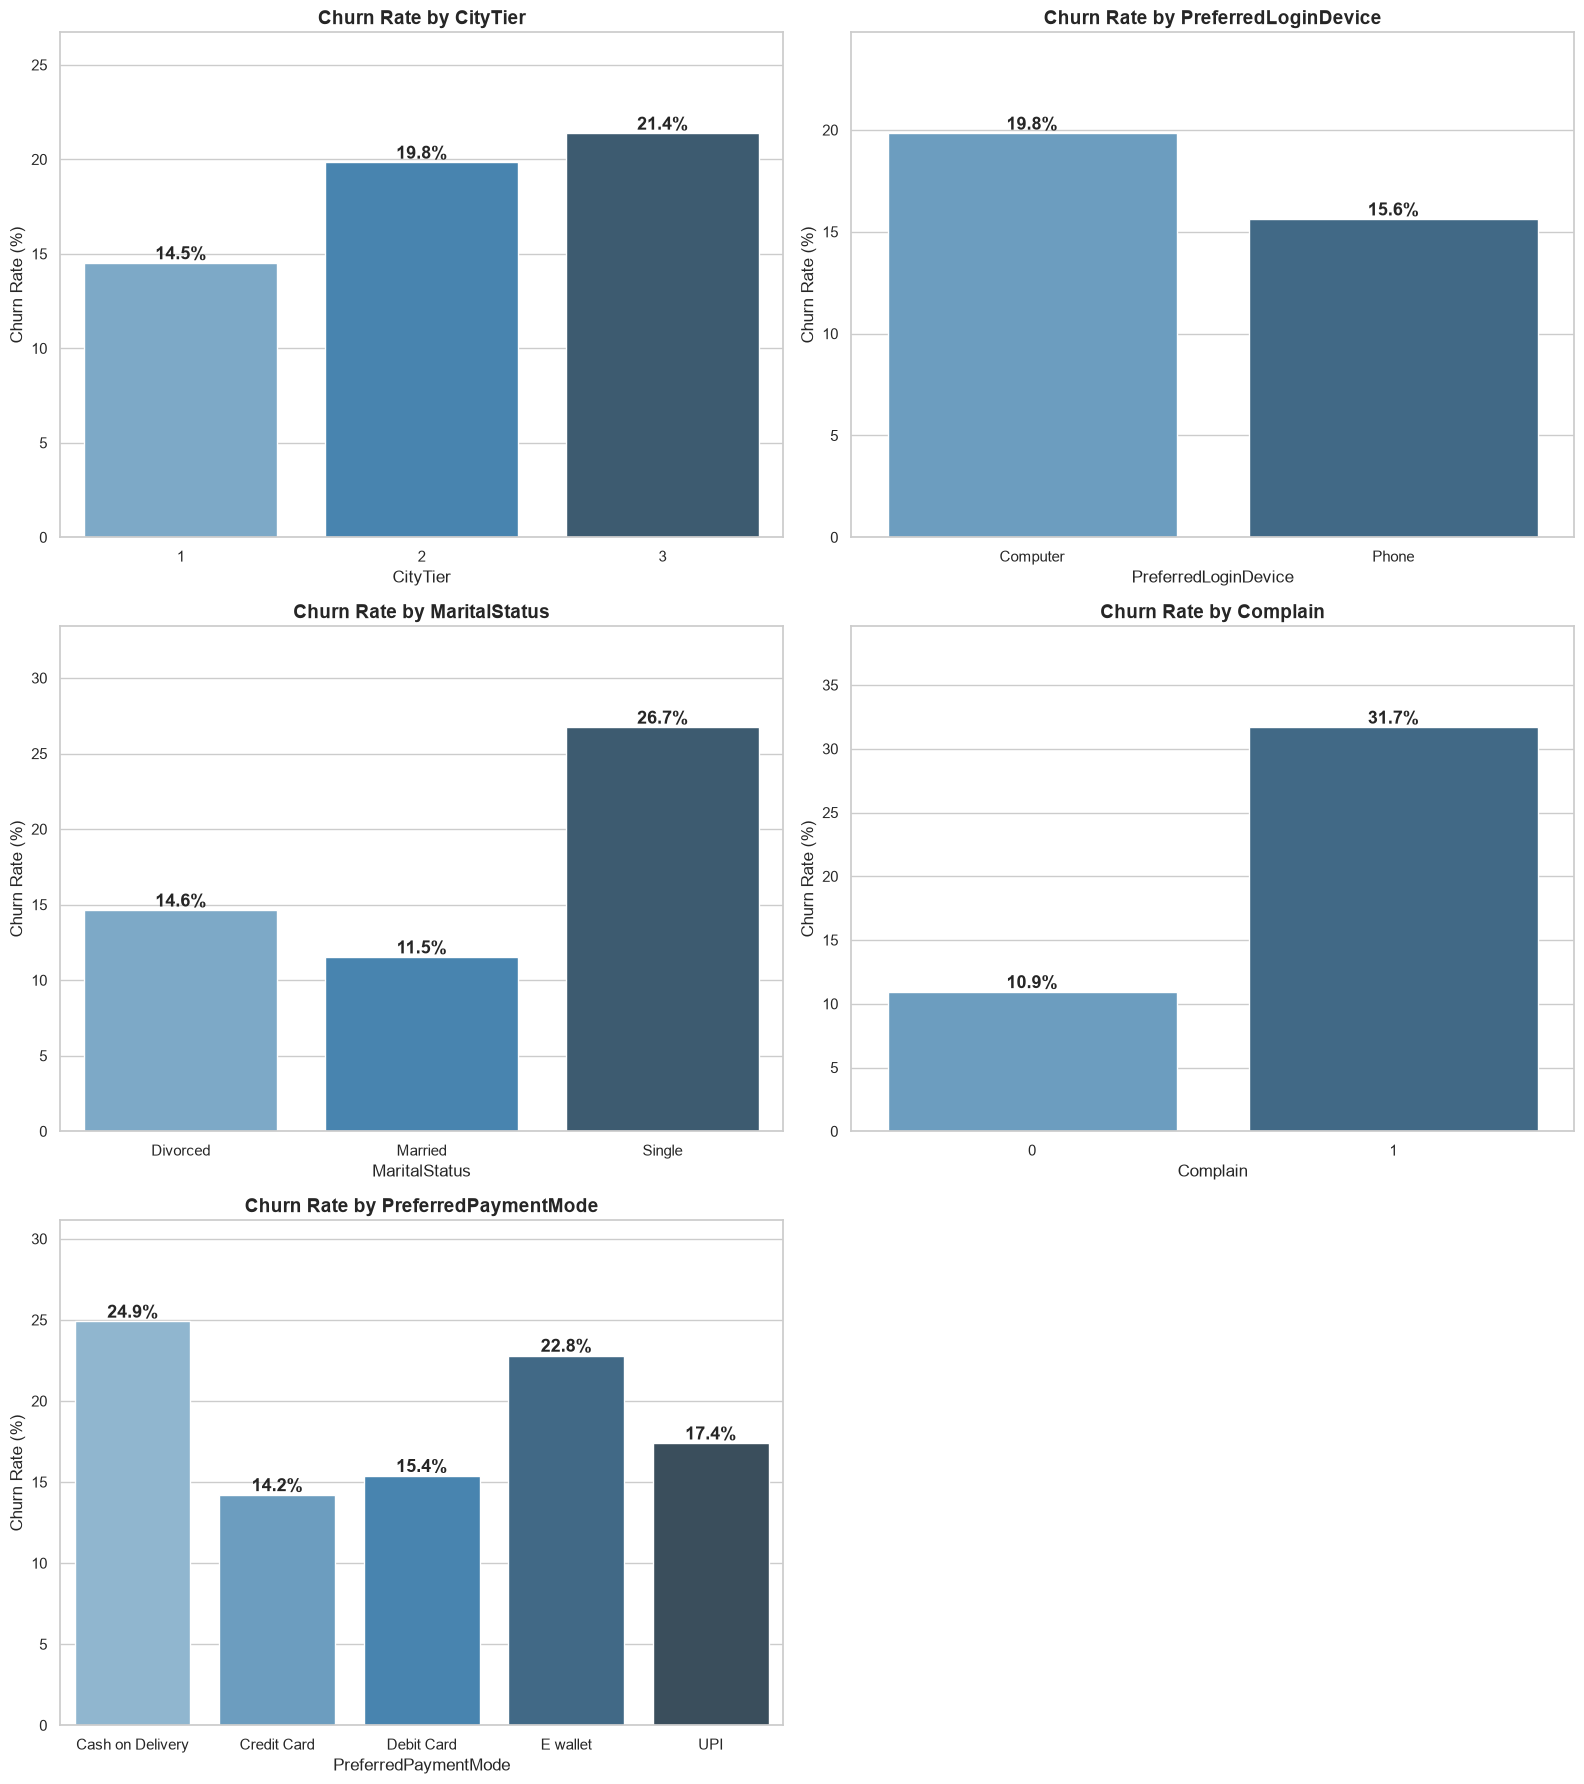

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(target_cols):
    data = df.groupby(col)["Churn"].mean().reset_index()
    data["Churned_Pct"] = data["Churn"] * 100
    print(data["Churned_Pct"].head(5))
    
    ax = axes[idx]
    sns.barplot(
        data=data,
        x=col,
        y="Churned_Pct",
        ax=ax,
        palette="Blues_d"
    )  
    
    ax.set_title(f"Churn Rate by {col}", fontsize=14, fontweight="bold")  
    ax.set_ylabel(f"Churn Rate (%)", fontsize=12)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylim(0, max(data["Churned_Pct"]) * 1.25)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )
        
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Correlation heatmap for numeric features.**

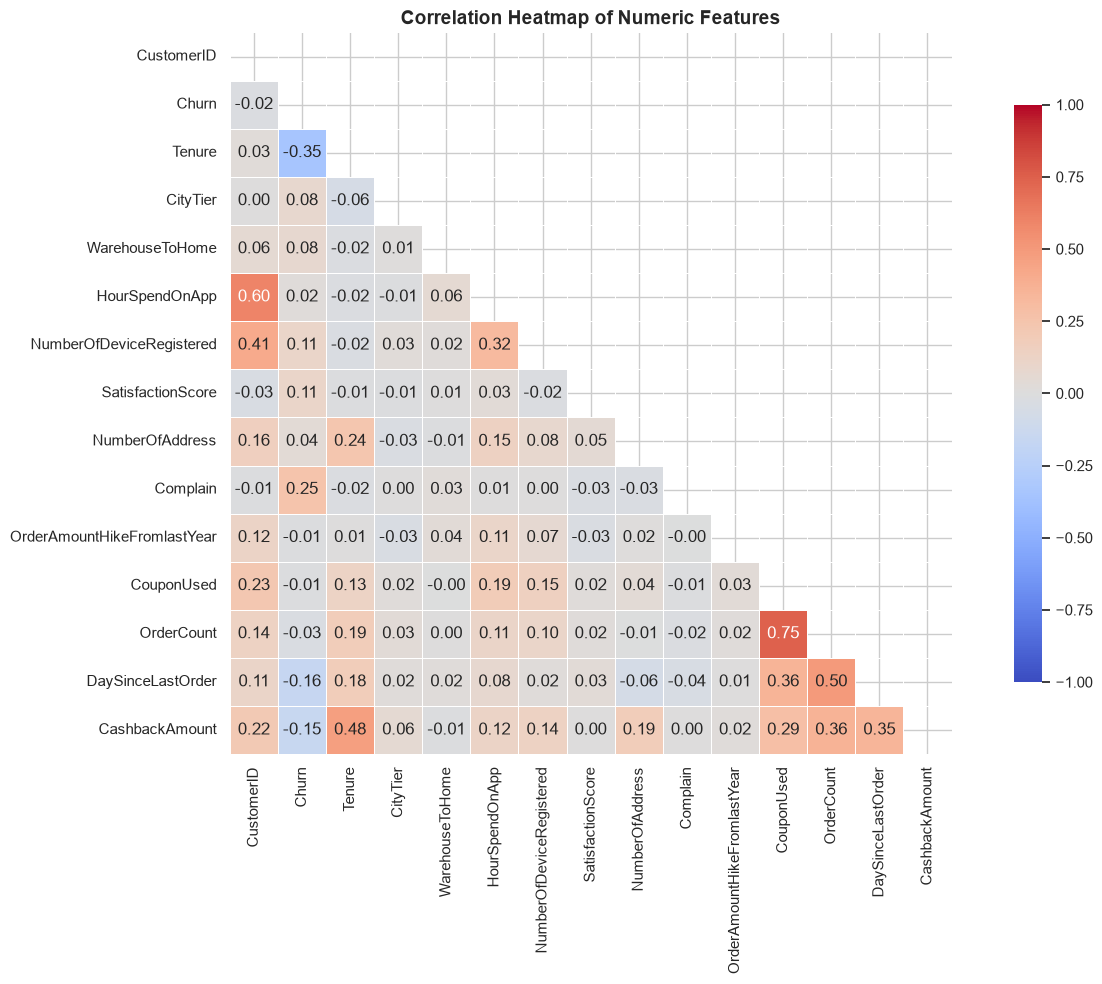

In [21]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    data=corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**My findings after the heatmap:**

1- The company coupon approach benefits it with higher order counts, it highly correlated with score of 0.75.

2- The company is good with cash back policy since it lead to more tenure for customers correlated 0.48.

3- The more the customer gets cash back the more they order from the ecommerce .